In [1]:
import cdms
import numpy as np
import os, sys 
from ROOT import *
from cats.cdataframe import CDataFrame
from CDMSDataCatalog import CDMSDataCatalog
import supercuts

import matplotlib.pyplot as plt
%matplotlib inline

CDMS = os.environ["CDMS"] # set in .bash_profile
stylesheet = os.path.join(CDMS,"scripts","stylesheets","steel.mplstyle")
plt.style.use(stylesheet)

sys.path.append(os.path.join(os.path.join(CDMS,"scripts")))
import setup

Welcome to JupyROOT 6.28/10


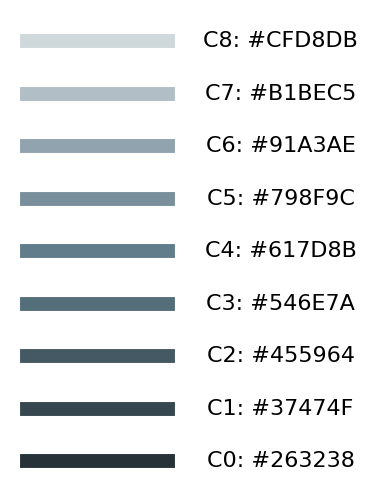

In [2]:
setup.show_colors(stylesheet)

In [3]:
Ge_decay = np.array([10.3670, 1.2990, 1.1432, 0.1595, 0.1035])
Ge_I = np.array([87.58, 10.44, 0.05, 1.92, 0.01])

(-1.0, 11.0)

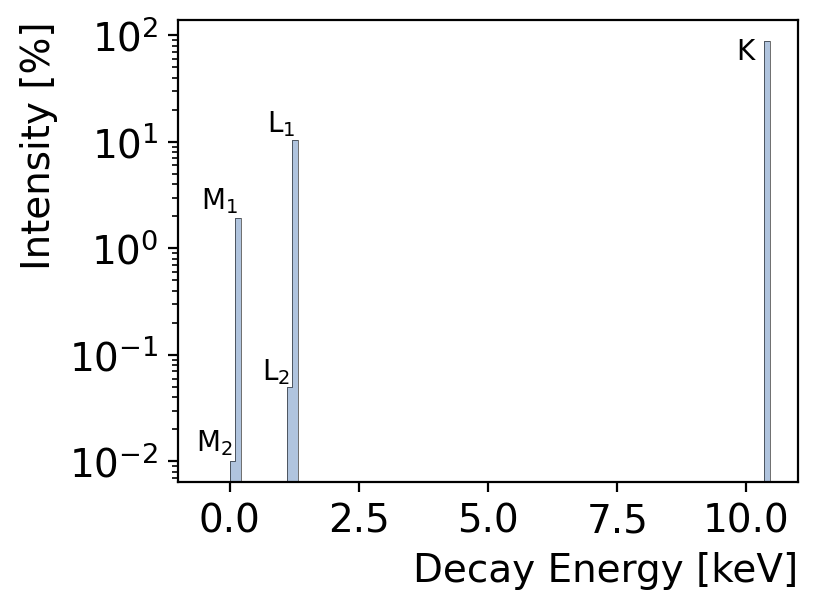

In [5]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(Ge_decay, bins=np.linspace(0, 11, 101), weights = Ge_I, color = 'lightsteelblue')
plt.hist(Ge_decay, bins=np.linspace(0, 11, 101), weights = Ge_I, histtype='step', color = 'black', lw = 0.2)

plt.text(10, 7e1, r'$\mathrm{K}$', ha='center', va='center', family='serif', fontsize = 10)
plt.text(1, 1.5e1, r'$\mathrm{L_1}$', ha='center', va='center', family='serif', fontsize = 10)
plt.text(0.9, 0.7e-1, r'$\mathrm{L_2}$', ha='center', va='center', family='serif', fontsize = 10)
plt.text(-0.2, 2.8e0, r'$\mathrm{M_1}$', ha='center', va='center', family='serif', fontsize = 10)
plt.text(-0.3, 1.5e-2, r'$\mathrm{M_2}$', ha='center', va='center', family='serif', fontsize = 10)

plt.yscale('log')
plt.xlabel(r"Decay Energy [keV]", loc = 'right')
plt.ylabel("Intensity [%]", loc = 'top')
plt.xlim(-1, 11)

[CDMS ELOG](https://scdms.slac.stanford.edu/elog/CUTE+Detectors/66): The neutron source was last deployed Dec. 12th at 15:22 to Dec. 13th at 08:55 (17 hours, 33 minutes). It doesn't seem that any other source exposures occurred before the following Ge series were taken.

In [6]:
# Time frame of source exposure in Unix time
source_start = 1702412520
source_end = 1702475700

[CUTE at SNOLAB](https://arxiv.org/pdf/2310.07930): The activity of the neutron source is 37.5 kBq.\
This gives us a total of $2.369 \times 10^9$ decays during the exposure period.

Need a simulation of Cf-252 source in the CUTE geometry to tell us how many neutrons are captured in the detector.

In [7]:
## Identify series list and pull data from data catalog
## Z1 held at 50V bias.

series_list=['23231216_013604', '23231216_043946', '23231216_100125', '23231216_145300', '23231216_182937', '23231216_194929', '23231216_211119', '23231216_233807', 
             '23231217_135018', '23231217_171613', '23231217_212512', '23231218_093255', '23231218_152721', '23231218_190035', '23231218_223530', '23231219_034952', 
             '23231219_110331', '23231219_184002', '23231216_115012', '23231220_012745'] # Ge calibration  

#series_list=['23240109_075338', '23240109_021236', '23240108_203134', '23240102_125359', '23240102_071256', '23240102_013155', '23231226_201731', '23231221_101235', 
#             '23231221_090636', '23231221_084447', '23231221_015705', '23231220_190923', '23231220_122140', '23231220_053358', '23231220_012745', '23231219_184002', 
#             '23231219_110331', '23231219_034952', '23231218_223530', '23231218_190035', '23231218_152721', '23231218_093255', '23231218_024511', '23231217_212512', 
#             '23231217_171613', '23231217_171055', '23231217_135018', '23231216_233807', '23231216_211119', '23231216_194929', '23231216_182937', '23231216_173436', 
#             '23231216_145300', '23231216_115012', '23231216_100125', '23231216_043946', '23231216_013604']

dc = CDMSDataCatalog().findData(
    Facility    = "CUTE",
    nFridgeRun  = 37,
    Series      = series_list,
    ProdTag     = "CUTE_T3_GeActivation_v2.1.1_V05-00_P0.2.",
    nMergeLevel = 1,
    dofetch     = True
)

filepath = [x.filePath for x in dc]
det = 1 # detector number
df = CDataFrame("rqDir/zip"+str(det), filepath, friends = [[x+":rqDir/eventTree" for x in filepath]])

In [8]:
## Apply some basic data quality filters and get the RQs you're interested in
logfile = '"cute_tower3testing.log"'
df = df.Define("LEDLogFile", logfile) 
df = df.CDefine("LEDOn", supercuts.ledOn_old, ["EventTime", "LEDLogFile"])
df = df.Filter("!LEDOn")
df_filtered = df.Filters(["TriggerType == 1", "TriggerDetectorNum=="+str(det), "PTOFamps>0"])

In [9]:
RQs = (["PTOFamps","PTOFchisqLF", "PTOFdelay", "EventNumber"] + 
       ['P' + label + 'S' + sequence + 'OFamps' for sequence in ['1', '2'] for label in ['A', 'B', 'C', 'D', 'E', 'F']])
df_rqs = df_filtered.AsNumpy(RQs)

Text(0, 1, 'PTOFchisqLF')

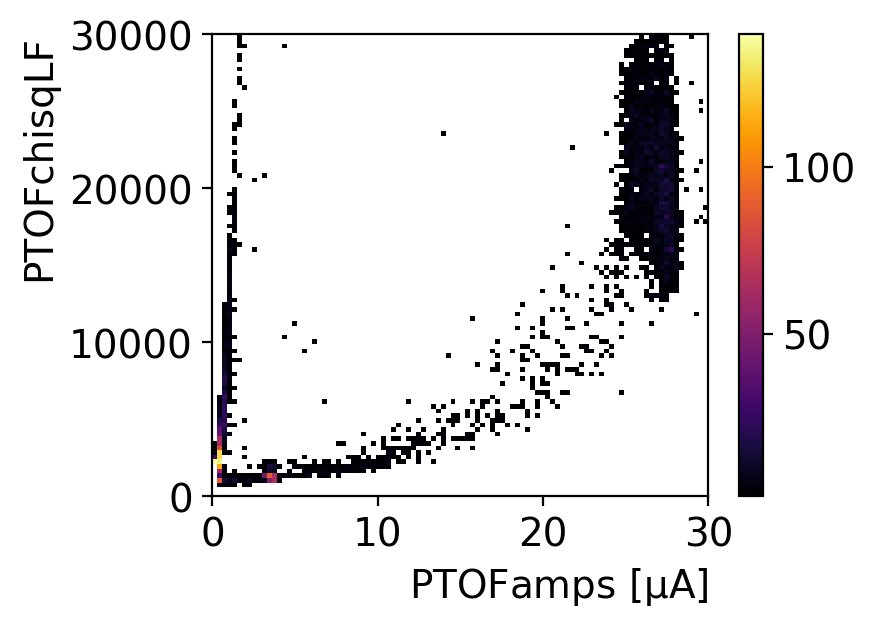

In [10]:
## Have a look at the PTOFamps vs chisq to make more cuts

plt.figure(figsize=(4,3), dpi=200)
plt.hist2d(df_rqs["PTOFamps"]*1e6,df_rqs["PTOFchisqLF"],bins=(np.linspace(0, 30, 101),np.linspace(0, 30e3, 101)),cmin=1e-7,cmax=200)
plt.colorbar()
plt.xlim(0,30)

plt.xlabel(r"PTOFamps [$\mathrm{\mu A}$]")
plt.ylabel("PTOFchisqLF")

Text(0, 1, 'Count / $\\mathrm{\\mu A}$')

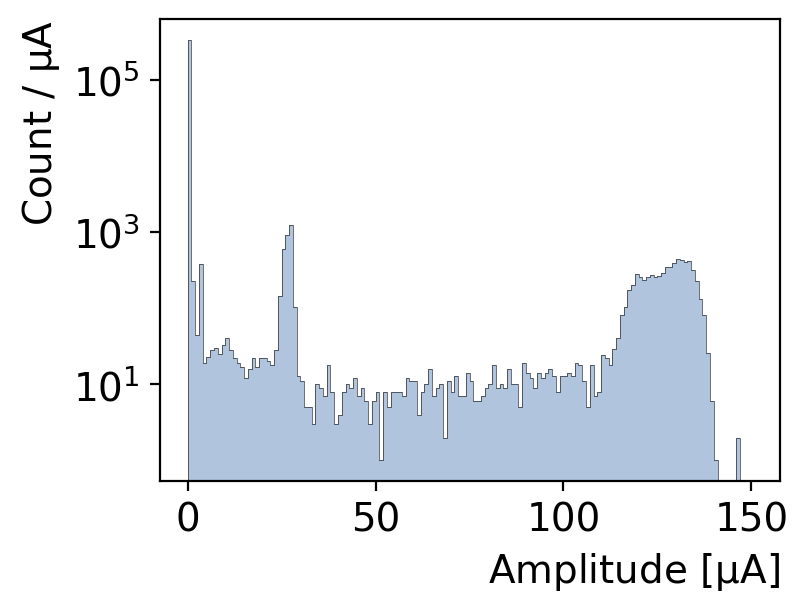

In [11]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(df_rqs['PTOFamps']*1e6, bins=np.linspace(0, 150, 151), color = 'lightsteelblue')
plt.hist(df_rqs['PTOFamps']*1e6, bins=np.linspace(0, 150, 151), histtype='step', color = 'black', lw = 0.2)
plt.yscale('log')
plt.xlabel(r"Amplitude [$\mathrm{\mu A}$]")
plt.ylabel("Count / $\mathrm{\mu A}$")

(0.0, 500.0)

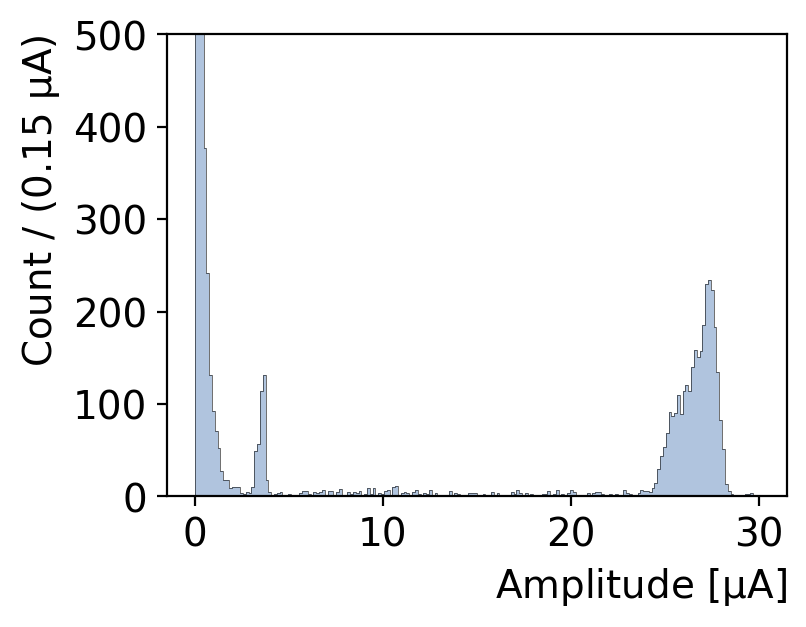

In [12]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(df_rqs['PTOFamps']*1e6, bins=np.linspace(0, 30, 201), color = 'lightsteelblue')
plt.hist(df_rqs['PTOFamps']*1e6, bins=np.linspace(0, 30, 201), histtype='step', color = 'black', lw = 0.2)
plt.xlabel(r"Amplitude [$\mathrm{\mu A}$]")
plt.ylabel("Count / (0.15 $\mathrm{\mu A}$)")
plt.ylim(0, 500)

(0.0, 50.0)

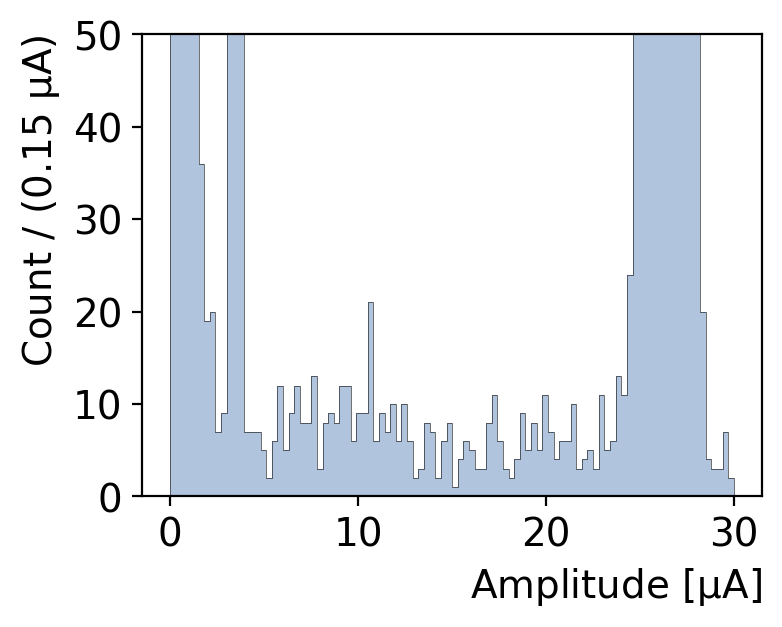

In [13]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(df_rqs['PTOFamps']*1e6, bins=np.linspace(0, 30, 101), color = 'lightsteelblue')
plt.hist(df_rqs['PTOFamps']*1e6, bins=np.linspace(0, 30, 101), histtype='step', color = 'black', lw = 0.2)
plt.xlabel(r"Amplitude [$\mathrm{\mu A}$]")
plt.ylabel("Count / (0.15 $\mathrm{\mu A}$)")
plt.ylim(0, 50)

Text(0, 1, 'Count / (0.3 $\\mathrm{\\mu A}$)')

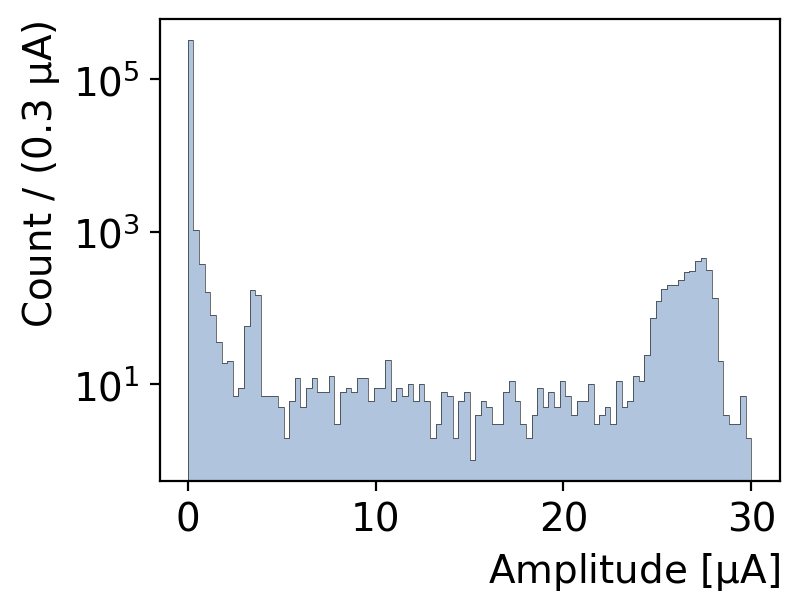

In [14]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(df_rqs['PTOFamps']*1e6, bins=np.linspace(0, 30, 101), color = 'lightsteelblue')
plt.hist(df_rqs['PTOFamps']*1e6, bins=np.linspace(0, 30, 101), histtype='step', color = 'black', lw = 0.2)
plt.yscale('log')
plt.xlabel(r"Amplitude [$\mathrm{\mu A}$]")
plt.ylabel("Count / (0.3 $\mathrm{\mu A}$)")

Text(0, 1, 'Count / (0.25 dex)')

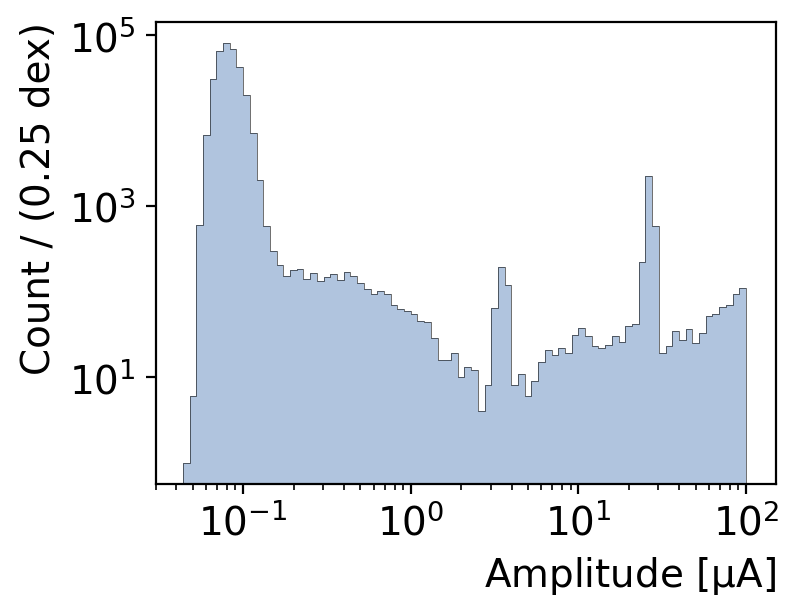

In [15]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(df_rqs['PTOFamps']*1e6, bins=np.logspace(-2, 2, 101), color = 'lightsteelblue')
plt.hist(df_rqs['PTOFamps']*1e6, bins=np.logspace(-2, 2, 101), histtype='step', color = 'black', lw = 0.2)
plt.yscale('log')
plt.xscale('log')
plt.xlim(3e-2, 1.5e2)
plt.xlabel(r"Amplitude [$\mathrm{\mu A}$]")
plt.ylabel("Count / (0.25 dex)")